Tspan (yr) = 14.962   df (nHz) = 2.1179
rho: qcw = 0.3036  loki = 0.000179


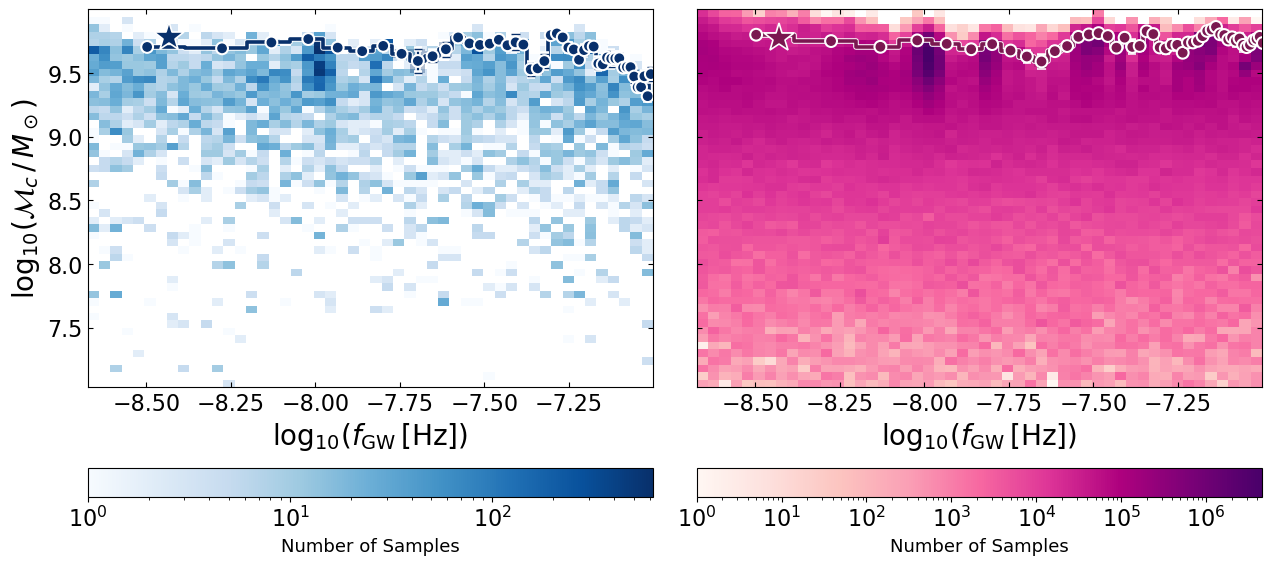

In [2]:
# %% [markdown]
# Frequency-segmented 95% Mc UL, side by side: left QuickCW (Blues), right QuickCW-dL (RdPu).
# 95% UL step + error band + star at the EM frequency (fixed-run ULs from Runs D, M).
# Per-bin uncertainties use n_eff = n_bin * rho with rho = min(1, ESS_raw/N_masked).
# %%
%matplotlib inline
import numpy as np
import h5py
import pickle
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import colors
from scipy.stats import gaussian_kde
import emcee

np.random.seed(42)
TARGET_DL = 75.4; TOL = 0.01; NMIN = 50; CONF = 0.95
mpc = 3.086e22; c = 299792458.0; T_sun = 1.327124400e20 / c**3
THIN_TAU = 10
QCW  = '/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_broad_UL_4core_outfile.h5'
LOKI = '/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D2_broad_UL_loki_100M_lastTOA_4core.h5'
F_EM = np.log10(3.7e-9)
STAR = {'qcw': 9.786, 'loki': 9.772}    # log10 Mc 95% UL from the fixed runs (D, M)
# %%
ps = pickle.load(open('/scratch/na00078/projects/IPTA_MDC2/IPTA_MDC2_data/psr_objects/G2D1_IPTA_MDC2_all_pulsars.pkl', 'rb'))
Tspan = max(p.toas.max() for p in ps) - min(p.toas.min() for p in ps)
print('Tspan (yr) =', round(Tspan / (365.25 * 86400), 3), '  df (nHz) =', round(1e9 / Tspan, 4))
# %%
def col(f, name):
    pn = [x.decode() for x in f['par_names'][:]]
    return f['samples_cold'][0, :, pn.index(name)]

def tau_of(x):
    xt = x[::THIN_TAU] if len(x) > 5_000_000 else x
    try:
        t = float(emcee.autocorr.integrated_time(xt, quiet=True)[0])
        return t * (THIN_TAU if len(x) > 5_000_000 else 1)
    except Exception:
        return 1.0

def get_fgw_mc(path, kind):
    with h5py.File(path, 'r') as f:
        fgw = col(f, '0_log10_fgw')
        mc  = col(f, '0_log10_mc')
        if kind == 'qcw':
            h  = 10 ** col(f, '0_log10_h')
            dL = 2 * (10**mc * T_sun)**(5/3) * (np.pi * 10**fgw)**(2/3) / h * c / mpc
        else:
            dL = 10 ** col(f, '0_log10_dist')
    tau = tau_of(mc)
    m = (dL >= TARGET_DL * (1 - TOL)) & (dL <= TARGET_DL * (1 + TOL))
    rho = min(1.0, (len(mc) / tau) / max(m.sum(), 1))
    return fgw[m], mc[m], rho

def segmented_ul(log10_fgw, log10_mc, Tspan, rho):
    fgw = 10**log10_fgw; mc = 10**log10_mc
    df = 1.0 / Tspan
    edges = np.arange(fgw.min(), fgw.max() + df, df)
    centers = 0.5 * (edges[:-1] + edges[1:])
    inds = np.digitize(fgw, edges) - 1
    fc, ul, ue = [], [], []
    for i in range(len(edges) - 1):
        samp = mc[inds == i]
        if len(samp) < NMIN:
            continue
        u = np.quantile(samp, CONF)
        sub = samp if len(samp) <= 200_000 else np.random.choice(samp, 200_000, replace=False)
        fq = gaussian_kde(sub).evaluate([u])[0]
        n_eff = max(len(samp) * rho, 1.0)
        fc.append(centers[i]); ul.append(u)
        ue.append(np.sqrt(CONF * (1 - CONF)) / (fq * np.sqrt(n_eff)))
    fc, ul, ue = map(np.array, (fc, ul, ue))
    return np.log10(fc), np.log10(ul), ue / (ul * np.log(10))
# %%
qf, qm, qrho = get_fgw_mc(QCW,  'qcw')
lf, lm, lrho = get_fgw_mc(LOKI, 'loki')
q = segmented_ul(qf, qm, Tspan, qrho)
l = segmented_ul(lf, lm, Tspan, lrho)
print('rho: qcw =', round(qrho, 4), ' loki =', round(lrho, 6))
# %%
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
panels = [(axes[0], qf, qm, q, 'Blues', '#08306b', 'qcw'),
          (axes[1], lf, lm, l, 'RdPu',  '#7a1750', 'loki')]
stroke = [pe.withStroke(linewidth=4, foreground='white')]
for ax, sf, sm, (x, y, ye), cmap, ulc, kind in panels:
    im = ax.hist2d(sf, sm, bins=50, norm=colors.LogNorm(), cmap=cmap)[3]
    ax.step(x, y, where='mid', color=ulc, lw=2.6, zorder=3, path_effects=stroke)
    ax.fill_between(x, y - ye, y + ye, step='mid', color=ulc, alpha=0.30, lw=0, zorder=2)
    ax.errorbar(x, y, yerr=ye, fmt='o', color=ulc, ecolor=ulc, elinewidth=1.6,
                capsize=3, lw=0, zorder=4, path_effects=stroke)
    ax.plot(F_EM, STAR[kind], marker='*', ms=22, color=ulc,
            mec='white', mew=1.2, zorder=5)
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.15)
    cb.set_label('Number of Samples', fontsize=13)
    ax.tick_params(direction='in', top=True, right=True, which='both')
    ax.set_xlabel(r'$\log_{10}(f_{\rm GW}\,[{\rm Hz}])$', fontsize=20)
axes[0].set_ylabel(r'$\log_{10}(\mathcal{M}_c\,/\,M_\odot)$', fontsize=20)
plt.tight_layout()
fig.savefig('G2D1_broad_freq_segmented_UL_sidebyside_4core.pdf', bbox_inches='tight')
plt.show()